<a href="https://colab.research.google.com/github/nfry25/CUDA-CNN-Quantization/blob/main/CIFAR10_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 CNN on CUDA C Kernels — Train, Evaluate, and Quantize

> Runtime: **A100 GPU, High-RAM**



### Cell 1.1 — Verify Runtime

In [1]:
# Verifying Runtime Hardware: A100
!nvidia-smi

Fri May 22 10:11:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Verifying Runtime Hardware: CPU & RAM
import os, multiprocessing

print("CPU cores visible:", multiprocessing.cpu_count())
print("RAM (GB):", round(os.sysconf('SC_PAGE_SIZE')*os.sysconf('SC_PHYS_PAGES')/1e9, 1))

CPU cores visible: 12
RAM (GB): 179.4


### Cell 1.2 — Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Folder in Drive that holds the CIFAR-10 .bin files.
DRIVE_DATA_DIR = '/content/drive/MyDrive/CIFAR10'
import os
print("Files found:", os.listdir(DRIVE_DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found: ['batches.meta.txt', 'data_batch_1.bin', 'data_batch_2.bin', 'data_batch_3.bin', 'test_batch.bin', 'data_batch_4.bin', 'data_batch_5.bin']


### Cell 1.3 — Stage the CUDA C modules

In [4]:
# Point this at the Drive folder containing the .cu/.h toolkit files.
DRIVE_CODE_DIR = '/content/drive/MyDrive/nn_cuda'
!mkdir -p /content/nn_cuda
!cp {DRIVE_CODE_DIR}/*.cu {DRIVE_CODE_DIR}/*.h /content/nn_cuda/ 2>/dev/null || echo "Copy the toolkit .cu/.h files into your Drive folder first."
!ls -la /content/nn_cuda


total 1172
drwxr-xr-x 2 root root    4096 May 22 08:15 .
drwxr-xr-x 1 root root    4096 May 22 07:05 ..
-rw------- 1 root root    2813 May 22 10:11 activations.cu
-rw------- 1 root root    3098 May 22 10:11 activations.h
-rw------- 1 root root    4747 May 22 10:11 conv_im2col.cu
-rw------- 1 root root    2854 May 22 10:11 conv_im2col.h
-rw------- 1 root root    9323 May 22 10:11 conv_layer.cu
-rw------- 1 root root    3634 May 22 10:11 conv_layer.h
-rw------- 1 root root    4648 May 22 10:11 fc_layer.cu
-rw------- 1 root root    3267 May 22 10:11 fc_layer.h
-rwxr-xr-x 1 root root 1126096 May 22 08:15 libnncuda.so
-rw------- 1 root root    3285 May 22 10:11 nn_common.h
-rw------- 1 root root    1889 May 22 10:11 pooling_layer.cu
-rw------- 1 root root    1485 May 22 10:11 pooling_layer.h
-rw-r--r-- 1 root root     789 May 22 08:12 wrapper.cu


### Cell 2.1 — Load CIFAR-10

In [5]:
import numpy as np, glob, os

def load_cifar_bin(paths):
    xs, ys = [], []
    for p in sorted(paths):
        raw = np.fromfile(p, dtype=np.uint8).reshape(-1, 3073)
        ys.append(raw[:, 0])                              # label byte
        imgs = raw[:, 1:].reshape(-1, 3, 32, 32)          # C,H,W
        xs.append(imgs)
    X = np.concatenate(xs).astype(np.float32) / 255.0     # normalize
    y = np.concatenate(ys).astype(np.int64)
    return X, y

train_paths = glob.glob(os.path.join(DRIVE_DATA_DIR, 'data_batch_*.bin'))
test_paths  = [os.path.join(DRIVE_DATA_DIR, 'test_batch.bin')]
X_train, y_train = load_cifar_bin(train_paths)
X_test,  y_test  = load_cifar_bin(test_paths)

# Per-channel mean/std norm
mean = X_train.mean(axis=(0,2,3), keepdims=True)
std  = X_train.std (axis=(0,2,3), keepdims=True)
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

print("Train:", X_train.shape, y_train.shape, "| Test:", X_test.shape, y_test.shape)
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']


Train: (50000, 3, 32, 32) (50000,) | Test: (10000, 3, 32, 32) (10000,)


### Cell 2.2 — Verify Input

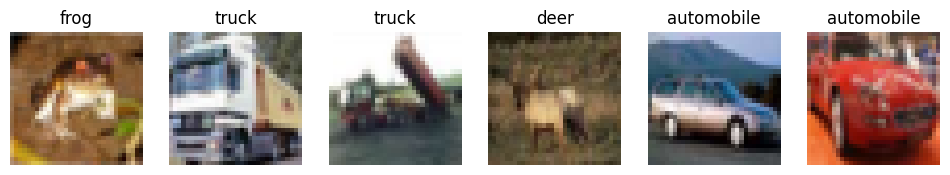

In [6]:
# Display Six Input Images
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 6, figsize=(12,2))
for i in range(6):
    img = (X_train[i]*std[0] + mean[0]).transpose(1,2,0)  # un-normalize for display
    ax[i].imshow(np.clip(img,0,1)); ax[i].set_title(classes[y_train[i]]); ax[i].axis('off')
plt.show()

### Cell 2.3 — Baseline Model (PyTorch & FP32)


Provides a **trusted reference accuracy and weight set**

Architecture of SmallCNN:

`Conv → ReLU → Pool → Conv → ReLU → Pool → FC → Softmax`.

In [7]:
import torch, torch.nn as nn, torch.nn.functional as F

# Select A100 for device
dev = 'cuda'

# Input: 3x32x32 RGB Images
# Output: features = number of classes (10)
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(3,  32, 3, padding=1)   # Conv. Layer 1
        self.c2 = nn.Conv2d(32, 64, 3, padding=1)   # Conv. Layer 2
        self.fc1 = nn.Linear(64*8*8, 256)
        self.fc2 = nn.Linear(256, 10)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.c1(x)), 2)      # Pool 1
        x = F.max_pool2d(F.relu(self.c2(x)), 2)      # Pool 2
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)                           # features; softmax in loss

model = SmallCNN().to(dev)
print(sum(p.numel() for p in model.parameters()), "parameters")


1070794 parameters


### Cell 2.4 — Baseline with SGD

In [8]:
from torch.utils.data import TensorDataset, DataLoader

# Train Dataloader
tr = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
                batch_size=256,
                shuffle=True,
                num_workers=8)

# Optimizer
opt = torch.optim.SGD(model.parameters(),
                      lr=0.05,
                      momentum=0.9,
                      nesterov=True,
                      weight_decay=5e-4)

# Loss Function: softmax & error
lossf = nn.CrossEntropyLoss()

# Training Loop
EPOCHS = 24

for ep in range(EPOCHS):
    model.train()
    running = 0.0

    for xb, yb in tr:
        xb, yb = xb.to(dev), yb.to(dev)
        opt.zero_grad()
        loss = lossf(model(xb), yb)     # forward, then error
        loss.backward()                 # backpropagate error derivative
        opt.step()                      # SGD update
        running += loss.item()*xb.size(0)


    print(f"epoch {ep+1:2d} | loss: {running/len(X_train):.5f}")


epoch  1 | loss: 1.47113
epoch  2 | loss: 0.97036
epoch  3 | loss: 0.75248
epoch  4 | loss: 0.60581
epoch  5 | loss: 0.46554
epoch  6 | loss: 0.34336
epoch  7 | loss: 0.24917
epoch  8 | loss: 0.18172
epoch  9 | loss: 0.14175
epoch 10 | loss: 0.11404
epoch 11 | loss: 0.09492
epoch 12 | loss: 0.07818
epoch 13 | loss: 0.06347
epoch 14 | loss: 0.05609
epoch 15 | loss: 0.04510
epoch 16 | loss: 0.03972
epoch 17 | loss: 0.03119
epoch 18 | loss: 0.02641
epoch 19 | loss: 0.02533
epoch 20 | loss: 0.01909
epoch 21 | loss: 0.01343
epoch 22 | loss: 0.00469
epoch 23 | loss: 0.00330
epoch 24 | loss: 0.00371


### Cell 2.5 — Baseline Metrics

**test accuracy, parameters, and model size**

In [9]:
import io

# Accuracy
def evaluate(m):
    m.eval(); correct = 0; preds_all=[]; tgts_all=[]
    with torch.no_grad():
        for i in range(0, len(X_test), 1000):
            xb = torch.tensor(X_test[i:i+1000]).to(dev)
            pred = m(xb).argmax(1).cpu().numpy()
            preds_all.append(pred); tgts_all.append(y_test[i:i+1000])
    preds = np.concatenate(preds_all); tgts = np.concatenate(tgts_all)
    return (preds==tgts).mean(), preds, tgts

# Model Size
def model_size_kb(m):
    buf = io.BytesIO(); torch.save(m.state_dict(), buf); return buf.tell()/1024

# Evaluation
baseline_acc, preds, tgts = evaluate(model)
baseline_params = sum((p!=0).sum().item() for p in model.parameters())  # active weights
baseline_kb = model_size_kb(model)

print(f"BASELINE  acc={baseline_acc*100:.2f}%  active_params={baseline_params:,}  size={baseline_kb:.0f} KB")


BASELINE  acc=75.71%  active_params=1,070,794  size=4186 KB


### Cell 2.6 — Per-class accuracy & confusion matrix

              precision    recall  f1-score   support

    airplane      0.781     0.794     0.787      1000
  automobile      0.864     0.861     0.863      1000
        bird      0.688     0.664     0.676      1000
         cat      0.567     0.558     0.562      1000
        deer      0.708     0.720     0.714      1000
         dog      0.675     0.657     0.666      1000
        frog      0.808     0.821     0.814      1000
       horse      0.805     0.809     0.807      1000
        ship      0.850     0.851     0.851      1000
       truck      0.816     0.836     0.826      1000

    accuracy                          0.757     10000
   macro avg      0.756     0.757     0.757     10000
weighted avg      0.756     0.757     0.757     10000



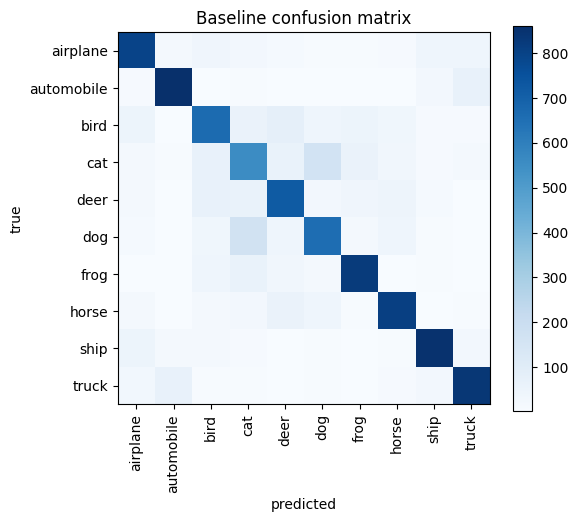

In [10]:
from sklearn.metrics import confusion_matrix, classification_report

# Classification & Confusion Matrix
cm = confusion_matrix(tgts, preds)
print(classification_report(tgts, preds, target_names=classes, digits=3))

# Visual
plt.figure(figsize=(6,5)); plt.imshow(cm, cmap='Blues')
plt.xticks(range(10), classes, rotation=90); plt.yticks(range(10), classes)
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Baseline confusion matrix'); plt.colorbar(); plt.show()


### Cell 3.1 — Where is Weight Redundancy

In [11]:
# Sorting Which Layers Hold Parameters
sizes = [(n, p.numel()) for n,p in model.named_parameters()]
sizes.sort(key=lambda t:-t[1])
total = sum(s for _,s in sizes)

print(f"{'layer':<14}{'params':>12}{'cumm %':>10}")
cumm=0
for n,s in sizes:
    cumm += s
    print(f"{n:<14}{s:>12,}{100*cumm/total:>9.1f}%")

layer               params    cumm %
fc1.weight       1,048,576     97.9%
c2.weight           18,432     99.6%
fc2.weight           2,560     99.9%
c1.weight              864    100.0%
fc1.bias               256    100.0%
c2.bias                 64    100.0%
c1.bias                 32    100.0%
fc2.bias                10    100.0%


### Cell 3.2 — Weight-Magnitude Distribution

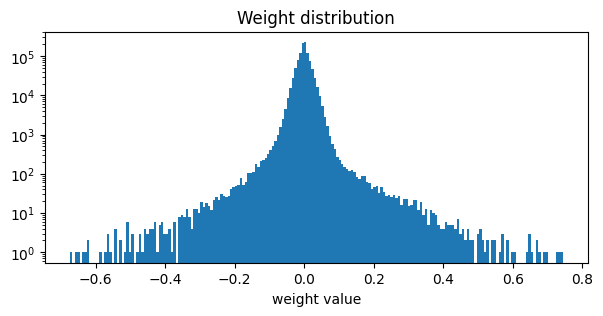

fraction of |w| < 0.01: 0.5183928934977222


In [12]:
w = np.concatenate([p.detach().cpu().numpy().ravel() for p in model.parameters()])

# Weight-Magnitude Distribution Visual
plt.figure(figsize=(7,3)); plt.hist(w, bins=200); plt.yscale('log')
plt.title('Weight distribution'); plt.xlabel('weight value'); plt.show()
print("fraction of |w| < 0.01:", (np.abs(w)<0.01).mean())

### Cell 4.1 — Iterative Magnitude Pruning (IMP)

In [13]:
import torch.nn.utils.prune as prune

# Global Pruning Function
def global_prune(m, amount):
    params = [(mod,'weight') for mod in m.modules()
              if isinstance(mod,(nn.Conv2d,nn.Linear))]
    prune.global_unstructured(params, pruning_method=prune.L1Unstructured, amount=amount)

# Fine-Tuning Loop
def finetune(m, epochs=5, lr=0.01):
    opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    m.train()
    for _ in range(epochs):
        for xb,yb in tr:
            xb,yb = xb.to(dev), yb.to(dev)
            opt.zero_grad()
            loss=lossf(m(xb),yb)
            loss.backward()
            opt.step()

# Accumulative Pruning Schedule
pruning_scheduler =  [
    0.35, 0.30,
    0.20, 0.20, 0.20,
    0.15, 0.15,
    0.10, 0.10, 0.10,
    0.05, 0.05, 0.05, 0.05,
    0.025, 0.025, 0.025, 0.025
]

for i, target in enumerate(pruning_scheduler):
    global_prune(model, target)
    finetune(model, epochs=5)
    acc,_,_ = evaluate(model)

    zeros = sum((mod.weight == 0).sum().item() for mod in model.modules() if isinstance(mod, (nn.Conv2d, nn.Linear)))
    total = sum(mod.weight.numel() for mod in model.modules() if isinstance(mod, (nn.Conv2d, nn.Linear)))
    sparsity = float(zeros / total)

    print(f"pruned {target*100:.0f}% | sparsity {sparsity*100:.1f}% "
          f"| compression {1/(1-sparsity):.1f}x | acc {acc*100:.2f}%")

# Remove Masks & Zero Weights
for mod in model.modules():
    if isinstance(mod,(nn.Conv2d,nn.Linear)):
        try: prune.remove(mod,'weight')
        except ValueError: pass

pruned 35% | sparsity 35.0% | compression 1.5x | acc 76.00%
pruned 30% | sparsity 54.5% | compression 2.2x | acc 76.01%
pruned 20% | sparsity 63.6% | compression 2.7x | acc 76.18%
pruned 20% | sparsity 70.9% | compression 3.4x | acc 75.92%
pruned 20% | sparsity 76.7% | compression 4.3x | acc 75.74%
pruned 15% | sparsity 80.2% | compression 5.1x | acc 75.31%
pruned 15% | sparsity 83.2% | compression 5.9x | acc 75.20%
pruned 10% | sparsity 84.9% | compression 6.6x | acc 75.16%
pruned 10% | sparsity 86.4% | compression 7.3x | acc 75.34%
pruned 10% | sparsity 87.7% | compression 8.1x | acc 75.32%
pruned 5% | sparsity 88.3% | compression 8.6x | acc 75.06%
pruned 5% | sparsity 88.9% | compression 9.0x | acc 75.22%
pruned 5% | sparsity 89.5% | compression 9.5x | acc 75.35%
pruned 5% | sparsity 90.0% | compression 10.0x | acc 74.99%
pruned 2% | sparsity 90.3% | compression 10.3x | acc 75.03%
pruned 2% | sparsity 90.5% | compression 10.5x | acc 74.85%
pruned 2% | sparsity 90.7% | compression 10

### Cell 4.2 — INT8 Quantization

In [14]:
# Quantize Model From FP32 to INT8
def quantize_tensor(t, num_bits=8):
    r_min, r_max = float(t.min()), float(t.max())
    qmax = 2**num_bits - 1
    S = (r_max - r_min) / qmax if r_max > r_min else 1.0    # scale factor
    Z = int(round(-r_min / S))                              # zero-point
    q = torch.clamp(torch.round(t/S) + Z, 0, qmax).to(torch.uint8)
    return q, S, Z

# r = S(q - Z)
def dequantize(q, S, Z):
    return S * (q.float() - Z)

# Quantize every conv/linear weight; keep pruned entries sparse
quant_store = {}
for n,p in model.named_parameters():
    if 'weight' in n:
        q,S,Z = quantize_tensor(p.data.cpu())
        quant_store[n] = {'q':q, 'S':S, 'Z':Z}
print("Quantized", len(quant_store), "weight tensors to INT8.")


Quantized 4 weight tensors to INT8.


### Cell 4b.1 — CUDA Conv Kernel to Python

In [15]:
wrapper = r"""

#include <cstdio>
#include "conv_layer.h"
#include "nn_common.h"

// C entry point: convolution, FP32, callable ctypes
extern "C" void cuda_conv2d(const float* h_X, const float* h_W, float* h_Y, int B, int M, int C, int H, int W, int K)  {
    int H_out=H-K+1, W_out=W-K+1;
    float *dX,*dW,*dY;
    size_t xb=(size_t)B*C*H*W*sizeof(float);
    size_t wb=(size_t)M*C*K*K*sizeof(float);
    size_t yb=(size_t)B*M*H_out*W_out*sizeof(float);

    cudaMalloc(&dX,xb);
    cudaMalloc(&dW,wb);
    cudaMalloc(&dY,yb);
    cudaMemcpy(dX,h_X,xb,cudaMemcpyHostToDevice);
    cudaMemcpy(dW,h_W,wb,cudaMemcpyHostToDevice);

    // tiled kernel
    conv_forward_tiled(dX,dW,dY,B,M,C,H,W,K);

    cudaMemcpy(h_Y,dY,yb,cudaMemcpyDeviceToHost);
    cudaFree(dX);
    cudaFree(dW);
    cudaFree(dY);
}
"""
open('/content/nn_cuda/wrapper.cu','w').write(wrapper)
print("wrapper.cu written")

wrapper.cu written


### Cell 4b.2 — Compile nvcc (A100 = sm_80)

In [16]:
# Change Directories
%cd /content/nn_cuda

# -arch=sm_80 targets compute capability; -shared builds a .so for ctypes.
!nvcc -O2 -arch=sm_80 -Xcompiler -fPIC -shared \
    conv_layer.cu activations.cu pooling_layer.cu fc_layer.cu conv_im2col.cu wrapper.cu \
    -o libnncuda.so && echo "BUILT"
!ls -la libnncuda.so

# Change Directories
%cd /content

/content/nn_cuda
BUILT
-rwxr-xr-x 1 root root 1126096 May 22 10:16 libnncuda.so
/content


### Cell 4b.3 — Validate CUDA kernel against PyTorch

In [17]:
import ctypes, numpy as np, torch, torch.nn.functional as F

lib = ctypes.CDLL('/content/nn_cuda/libnncuda.so')
lib.cuda_conv2d.argtypes = [ctypes.POINTER(ctypes.c_float)]*3 + [ctypes.c_int]*6

B,M,C,H,W,K = 2,4,3,32,32,3
X = np.random.randn(B,C,H,W).astype(np.float32)
Wt= np.random.randn(M,C,K,K).astype(np.float32)
Ho,Wo = H-K+1, W-K+1
Y = np.zeros((B,M,Ho,Wo), np.float32)

cf = lambda a: a.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
lib.cuda_conv2d(cf(X), cf(Wt), cf(Y), B,M,C,H,W,K)

ref = F.conv2d(torch.tensor(X), torch.tensor(Wt)).numpy()   # conv, no padding
err = np.abs(Y-ref).max()

print(f"Max absolute difference between CUDA vs PyTorch: {err:.2e} >", "MATCHING!" if err<1e-2 else "RE-CHECK")

Max absolute difference between CUDA vs PyTorch: 3.81e-06 > MATCHING!


### Cell 5.1 — Export Pruned & INT8 Model to Drive

In [18]:
import pickle, os

# Output Directory
OUT_DIR = '/content/drive/MyDrive/CIFAR_CUDA_Outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# Store INT8 weights in COO sparse form
export = {}
for n, d in quant_store.items():
    q = d['q']; nz = (q.flatten() != d['Z']).nonzero().flatten().numpy()
    export[n] = {'idx': nz.astype(np.int32),'val': q.flatten()[nz].numpy(),'shape': tuple(q.shape), 'S': d['S'], 'Z': d['Z']}
with open(os.path.join(OUT_DIR,'model_int8_sparse.pkl'),'wb') as f:
    pickle.dump(export, f)

comp_kb = os.path.getsize(os.path.join(OUT_DIR,'model_int8_sparse.pkl'))/1024
print(f"Exported compressed model: {comp_kb:.0f} KB  (baseline was {baseline_kb:.0f} KB)")


Exported compressed model: 473 KB  (baseline was 4186 KB)


### Cell 6.1 — Final Evaluation

In [19]:
# Re-evaluation and Final Metrics
sd = model.state_dict()
for n,d in quant_store.items():
    sd[n] = dequantize(d['q'], d['S'], d['Z']).reshape(sd[n].shape).to(dev)
model.load_state_dict(sd)
final_acc,_,_ = evaluate(model)

final_sparsity = float(sum((p==0).sum() for p in model.parameters()) /
                       sum(p.numel() for p in model.parameters()))

print("===================================================")
print(f"{'metric':<22}{'baseline':>12}{'compressed':>14}")
print(f"{'test accuracy (%)':<22}{baseline_acc*100:>12.2f}{final_acc*100:>14.2f}")
print(f"{'on-disk size (KB)':<22}{baseline_kb:>12.0f}{comp_kb:>14.0f}")
print(f"{'size reduction':<22}{'1.0x':>12}{baseline_kb/comp_kb:>13.1f}x")
print(f"{'sparsity (%)':<22}{0.0:>12.1f}{final_sparsity*100:>14.1f}")
print("===================================================")



metric                    baseline    compressed
test accuracy (%)            75.71         74.53
on-disk size (KB)             4186           473
size reduction                1.0x          8.9x
sparsity (%)                   0.0          90.9
